## 1. Imports and Settings

In [1]:
import os
from collections import Counter
from pathlib import Path
import re
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp")
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from wordcloud import WordCloud

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
BW_COLORS = ["#111111", "#666666", "#999999", "#D9D9D9"]
BW_HATCHES = ["///", "\\\\\\", "xx", "..", "++"]
BW_LINESTYLES = ["-", "--", "-.", ":"]
BW_MARKERS = ["o", "s", "^", "D"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})
pd.set_option("display.max_colwidth", 160)

## 1.1 Helper Functions

In [2]:
def basic_text_eda(data, label_col="label", text_col="text"):
    """Create reusable text statistics for EDA."""
    eda_df = data.copy()
    eda_df[text_col] = eda_df[text_col].fillna("").astype(str)
    eda_df["char_count"] = eda_df[text_col].str.len()
    eda_df["word_count"] = eda_df[text_col].str.split().str.len()
    eda_df["unique_word_count"] = eda_df[text_col].str.lower().str.findall(r"[a-zA-Z]{2,}").map(lambda words: len(set(words)))
    eda_df["avg_word_length"] = eda_df[text_col].str.findall(r"[a-zA-Z]+").map(
        lambda words: np.mean([len(word) for word in words]) if words else 0
    )
    return eda_df


def add_bar_labels(ax):
    for patch in ax.patches:
        height = patch.get_height()
        if np.isnan(height):
            continue
        ax.annotate(
            f"{height:,.0f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )


def show_label_distribution(data, label_col="label"):
    label_counts = data[label_col].value_counts().rename_axis(label_col).reset_index(name="count")
    label_counts["percentage"] = (label_counts["count"] / len(data) * 100).round(2)
    display(label_counts)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(
        label_counts[label_col],
        label_counts["count"],
        color=["white", "#E6E6E6", "#BFBFBF", "#8C8C8C"][: len(label_counts)],
        edgecolor="black",
        linewidth=1.2,
    )
    for idx, bar in enumerate(bars):
        bar.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])
    ax.set_title("Class Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Number of records")
    ax.tick_params(axis="x", rotation=20)
    add_bar_labels(ax)
    ax.margins(y=0.15)
    plt.tight_layout()
    plt.show()


def plot_text_lengths(eda_df, label_col="label"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    labels = sorted(eda_df[label_col].dropna().unique())
    upper_chars = eda_df["char_count"].quantile(0.95)
    bins = np.linspace(0, upper_chars, 35)

    for idx, label_value in enumerate(labels):
        clipped_chars = eda_df.loc[eda_df[label_col] == label_value, "char_count"].clip(upper=upper_chars)
        axes[0].hist(
            clipped_chars,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.8,
            color=BW_COLORS[idx % len(BW_COLORS)],
            linestyle=BW_LINESTYLES[idx % len(BW_LINESTYLES)],
            label=str(label_value),
        )
    axes[0].set_title("Character Count Distribution (95th percentile clipped)")
    axes[0].set_xlabel("Characters")
    axes[0].set_ylabel("Density")
    axes[0].legend(title="Class")

    upper_words = eda_df["word_count"].quantile(0.95)
    box_data = [
        eda_df.loc[eda_df[label_col] == label_value, "word_count"].clip(upper=upper_words)
        for label_value in labels
    ]
    box = axes[1].boxplot(
        box_data,
        tick_labels=labels,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5},
        boxprops={"edgecolor": "black", "linewidth": 1.2},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        flierprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 3,
        },
    )
    for idx, patch in enumerate(box["boxes"]):
        patch.set_facecolor(["white", "#E6E6E6", "#BFBFBF", "#8C8C8C"][idx % 4])
        patch.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])
    axes[1].set_title("Word Count by Class (95th percentile clipped)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Words")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


def top_words_by_label(data, label_value, text_col="text", label_col="label", n=20):
    text = " ".join(data.loc[data[label_col] == label_value, text_col].dropna().astype(str).str.lower())
    words = re.findall(r"[a-zA-Z]{3,}", text)
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return pd.DataFrame(Counter(words).most_common(n), columns=["word", "count"])


def wordcloud_text(data, label_value, text_col="text", label_col="label"):
    text = " ".join(data.loc[data[label_col] == label_value, text_col].dropna().astype(str))
    return text.strip() if text.strip() else "empty"


def plot_word_clouds(data, text_col="text", label_col="label"):
    labels = sorted(data[label_col].dropna().unique())
    fig, axes = plt.subplots(1, len(labels), figsize=(7 * len(labels), 5))
    if len(labels) == 1:
        axes = [axes]

    stopwords = set(ENGLISH_STOP_WORDS)
    for idx, label_value in enumerate(labels):
        wc = WordCloud(
            width=900,
            height=500,
            background_color="white",
            stopwords=stopwords,
            max_words=120,
            collocations=False,
            random_state=RANDOM_STATE,
            color_func=lambda *args, **kwargs: BW_COLORS[idx % 3],
        ).generate(wordcloud_text(data, label_value, text_col=text_col, label_col=label_col))
        axes[idx].imshow(wc, interpolation="bilinear")
        axes[idx].set_title(f"Word Cloud: {label_value}")
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()


def plot_top_words(words_df, title, n=15):
    plot_df = words_df.head(n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(
        plot_df["word"],
        plot_df["count"],
        color="white",
        edgecolor="black",
        linewidth=1.0,
    )
    for idx, bar in enumerate(bars):
        bar.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])
    ax.set_title(title)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


def plot_model_comparison(results_df):
    metrics_to_plot = ["accuracy", "weighted_f1", "roc_auc"]
    plot_df = results_df.set_index("model")[metrics_to_plot]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(plot_df.index))
    width = 0.24

    for idx, metric in enumerate(metrics_to_plot):
        values = plot_df[metric].values
        bars = ax.bar(
            x + (idx - 1) * width,
            values,
            width=width,
            label=metric,
            color=["white", "#E6E6E6", "#BFBFBF"][idx],
            edgecolor="black",
            linewidth=1.0,
        )
        for bar in bars:
            bar.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])

    ax.set_title("Model Comparison")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
    ax.legend(title="Metric")
    plt.tight_layout()
    plt.show()


def plot_decision_tree_preview(tree_pipeline, max_depth=3):
    vectorizer = tree_pipeline.named_steps["tfidf"]
    tree_model = tree_pipeline.named_steps["model"]
    feature_names = vectorizer.get_feature_names_out()

    plt.figure(figsize=(18, 8))
    plot_tree(
        tree_model,
        max_depth=max_depth,
        feature_names=feature_names,
        class_names=[str(value) for value in tree_model.classes_],
        filled=False,
        rounded=False,
        fontsize=8,
    )
    plt.title(f"Decision Tree Preview (first {max_depth} levels)")
    plt.tight_layout()
    plt.show()


def evaluate_model(name, model, X_train, X_test, y_train, y_test, positive_label):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "weighted_precision": precision,
        "weighted_recall": recall,
        "weighted_f1": f1,
    }

    print(f"{name} classification report")
    report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T
    display(report)

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Greys", values_format="d", xticks_rotation=30, colorbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    if len(labels) == 2:
        try:
            classes = list(model.classes_)
            positive_index = classes.index(positive_label)
            if hasattr(model, "predict_proba"):
                y_score = model.predict_proba(X_test)[:, positive_index]
            elif hasattr(model, "decision_function"):
                decision_scores = model.decision_function(X_test)
                if np.ndim(decision_scores) == 1:
                    # For binary LinearSVC, positive scores correspond to classes_[1].
                    y_score = decision_scores if positive_index == 1 else -decision_scores
                else:
                    y_score = decision_scores[:, positive_index]
            else:
                y_score = (y_pred == positive_label).astype(int)

            y_test_binary = (y_test == positive_label).astype(int)
            metrics["roc_auc"] = roc_auc_score(y_test_binary, y_score)
            RocCurveDisplay.from_predictions(
                y_test_binary,
                y_score,
                name=name,
                color="black",
                linestyle="-" if name == "Linear SVM" else "--",
                marker="o" if name == "Linear SVM" else "s",
                markevery=0.1,
                linewidth=1.8,
            )
            plt.title(f"{name} ROC Curve")
            plt.tight_layout()
            plt.show()
        except ValueError:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics, model

## 2. Load Dataset

In [3]:
DATA_PATH = Path(r"/home/durgaumadev/Documents/MTech/Security for Data Science/sms+spam+collection/SMSSpamCollection")
df = pd.read_csv(DATA_PATH, sep="\t", names=["label", "text"], header=None)

df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].astype(str)

## 3. Basic Structure

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

print("\nData types and missing values")
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}))

Shape: (5572, 2)

Columns: ['label', 'text']


,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"



Data types and missing values


,dtype,missing,missing_pct
label,str,0,0.0
text,str,0,0.0


## 4. Class Balance

,label,count,percentage
0,ham,4825,86.59
1,spam,747,13.41


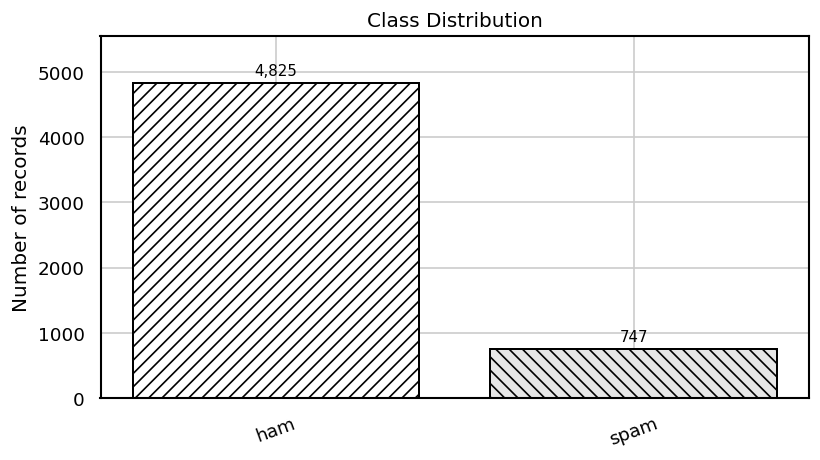

In [5]:
show_label_distribution(df, label_col="label")

## 5. Missing Values, Blank Text, and Duplicates

In [6]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "missing_text",
        "blank_text",
        "missing_label",
        "duplicate_rows",
        "duplicate_texts",
    ],
    "value": [
        len(df),
        df["text"].isna().sum(),
        df["text"].fillna("").str.strip().eq("").sum(),
        df["label"].isna().sum(),
        df.duplicated().sum(),
        df["text"].duplicated().sum(),
    ],
})
display(quality_summary)

display(df[df["text"].duplicated(keep=False)].sort_values("text").head(10))

,metric,value
0,rows,5572
1,missing_text,0
2,blank_text,0
3,missing_label,0
4,duplicate_rows,403
5,duplicate_texts,403


,label,text
505,spam,+123 Congratulations - in this week's competition draw u have won the £1450 prize to claim just call 09050002311 b4280703. T&Cs/stop SMS 08718727868. Over 1...
2124,spam,+123 Congratulations - in this week's competition draw u have won the £1450 prize to claim just call 09050002311 b4280703. T&Cs/stop SMS 08718727868. Over 1...
2344,ham,"1) Go to write msg 2) Put on Dictionary mode 3)Cover the screen with hand, 4)Press &lt;#&gt; . 5)Gently remove Ur hand.. Its interesting..:)"
1373,ham,"1) Go to write msg 2) Put on Dictionary mode 3)Cover the screen with hand, 4)Press &lt;#&gt; . 5)Gently remove Ur hand.. Its interesting..:)"
2163,ham,"1) Go to write msg 2) Put on Dictionary mode 3)Cover the screen with hand, 4)Press &lt;#&gt; . 5)Gently remove Ur hand.. Its interesting..:)"
1050,spam,18 days to Euro2004 kickoff! U will be kept informed of all the latest news and results daily. Unsubscribe send GET EURO STOP to 83222.
2719,spam,18 days to Euro2004 kickoff! U will be kept informed of all the latest news and results daily. Unsubscribe send GET EURO STOP to 83222.
2044,spam,4mths half price Orange line rental & latest camera phones 4 FREE. Had your phone 11mths ? Call MobilesDirect free on 08000938767 to update now! or2stoptxt
389,spam,4mths half price Orange line rental & latest camera phones 4 FREE. Had your phone 11mths ? Call MobilesDirect free on 08000938767 to update now! or2stoptxt
1779,ham,"7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st ""Ur Lovely Friendship""... good morning dear"


## 6. Text Length Analysis

char_count                                                  word_count  \
           count    mean    std   min    25%    50%    75%    max      count   
label                                                                          
ham       4825.0   71.48  58.44   2.0   33.0   52.0   93.0  910.0     4825.0   
spam       747.0  138.67  28.87  13.0  133.0  149.0  157.0  223.0      747.0   

              ... unique_word_count       avg_word_length                   \
        mean  ...               75%   max           count  mean   std  min   
label         ...                                                            
ham    14.31  ...              16.0  88.0          4825.0  3.71  0.70  0.0   
spam   23.91  ...              23.0  30.0           747.0  4.15  0.67  1.5   

                               
        25%   50%   75%   max  
label                          
ham    3.27  3.64  4.00  10.5  
spam   3.68  4.11  4.53  12.0  

[2 rows x 32 columns]

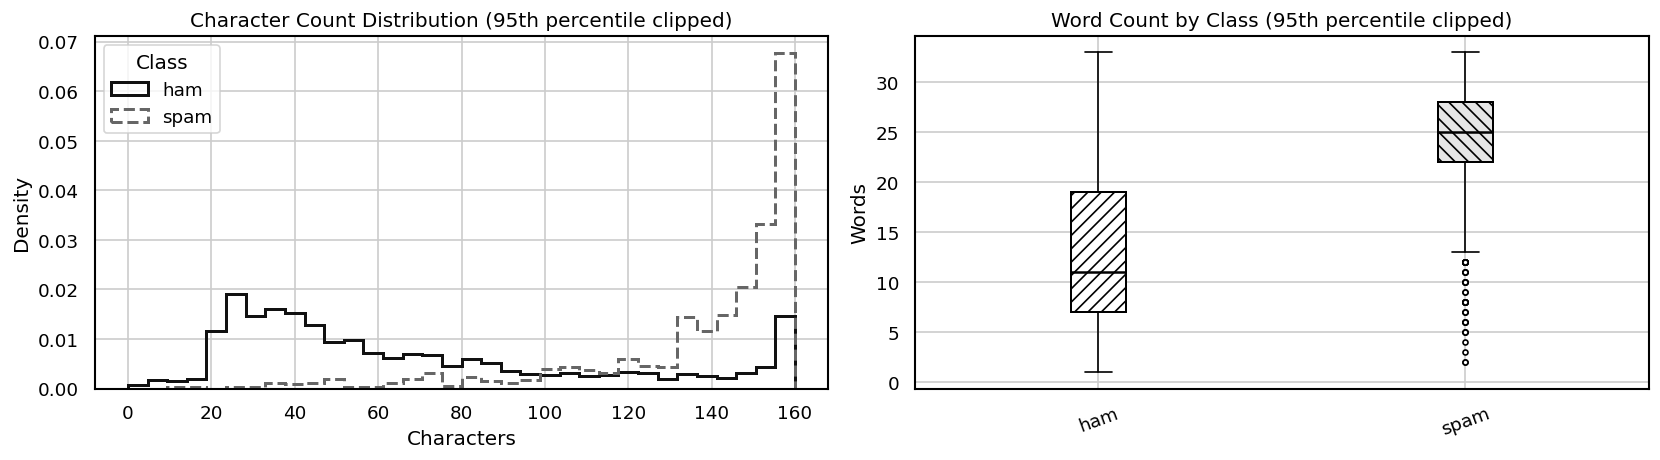

In [7]:
eda_df = basic_text_eda(df)

display(
    eda_df.groupby("label")[["char_count", "word_count", "unique_word_count", "avg_word_length"]]
    .describe()
    .round(2)
)

plot_text_lengths(eda_df)

## 7. Word Cloud Visualization

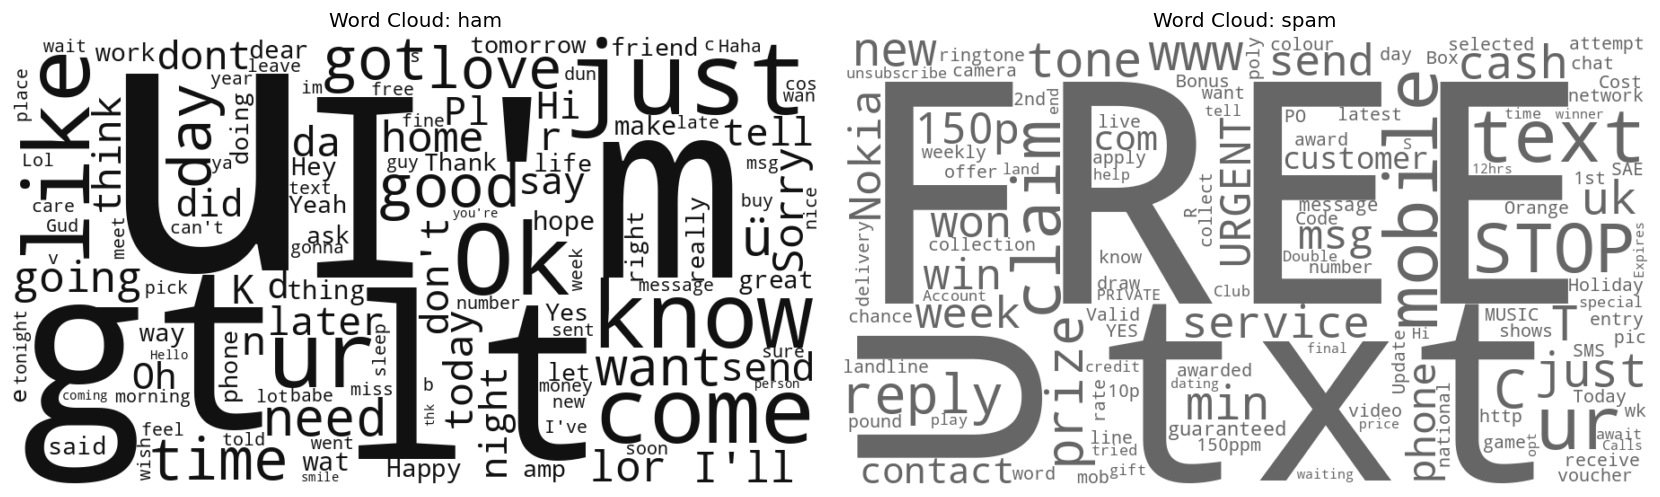

In [8]:
plot_word_clouds(df, text_col="text", label_col="label")

## 8. Most Frequent Words by Class

Top words for: ham


,word,count
0,just,297
1,know,237
2,good,235
3,got,234
4,like,234
5,come,231
6,day,218
7,love,205
8,time,202
9,going,169


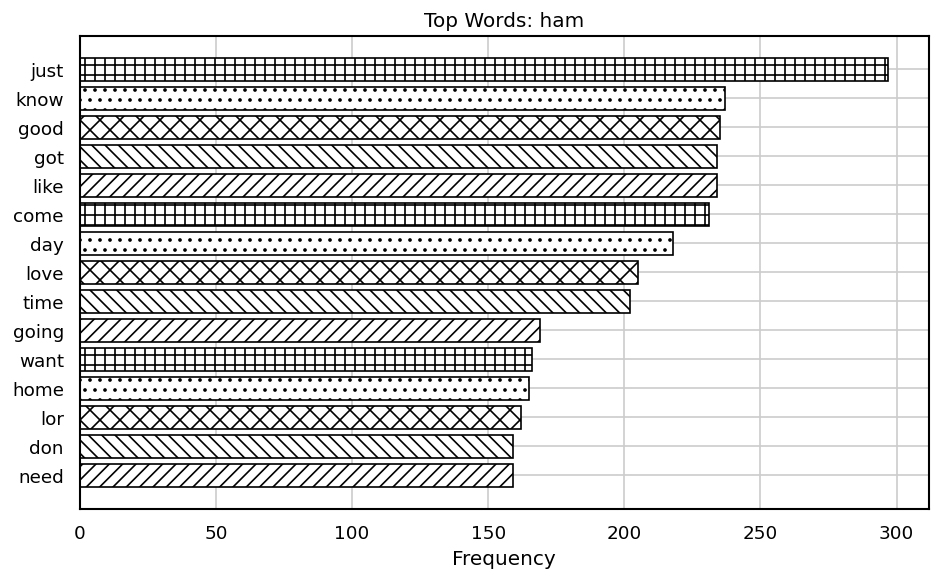

Top words for: spam


,word,count
0,free,228
1,txt,170
2,mobile,129
3,stop,128
4,text,126
5,claim,113
6,reply,104
7,www,98
8,prize,93
9,just,79


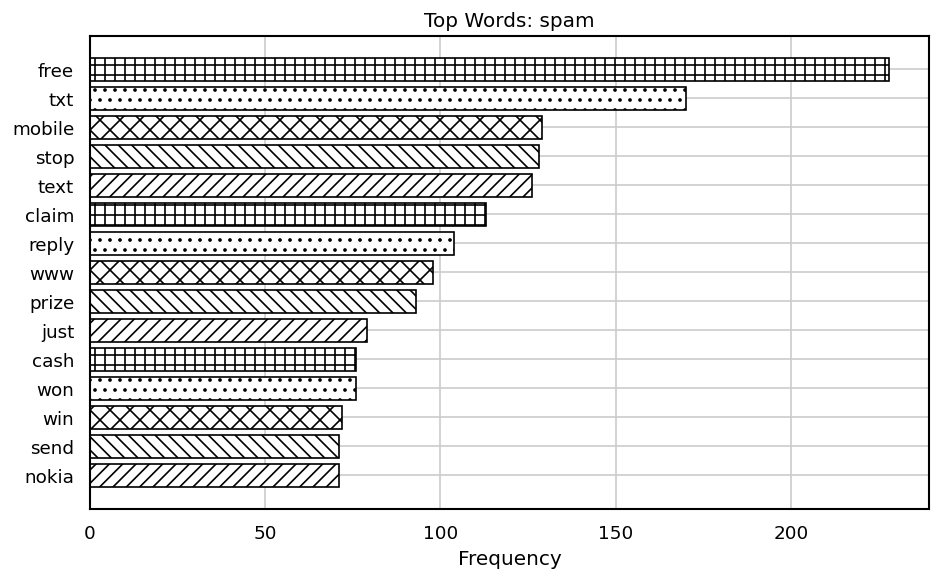

In [9]:
for label_value in sorted(df["label"].dropna().unique()):
    print(f"Top words for: {label_value}")
    words_df = top_words_by_label(df, label_value, n=20)
    display(words_df)
    plot_top_words(words_df, title=f"Top Words: {label_value}", n=15)

## 9. Text Representation Method

The text representation used for both models is **TF-IDF** using `TfidfVectorizer`.

TF-IDF means Term Frequency-Inverse Document Frequency. It converts text into numerical features by giving higher weight to words that are important in a document but not too common across the full dataset. This is a sparse vector representation, not a dense neural word embedding such as Word2Vec, GloVe, FastText, or BERT.

## 10. Prepare Data for Modeling

Rows after cleaning: 5169


,label,count,percentage
0,ham,4516,87.37
1,spam,653,12.63


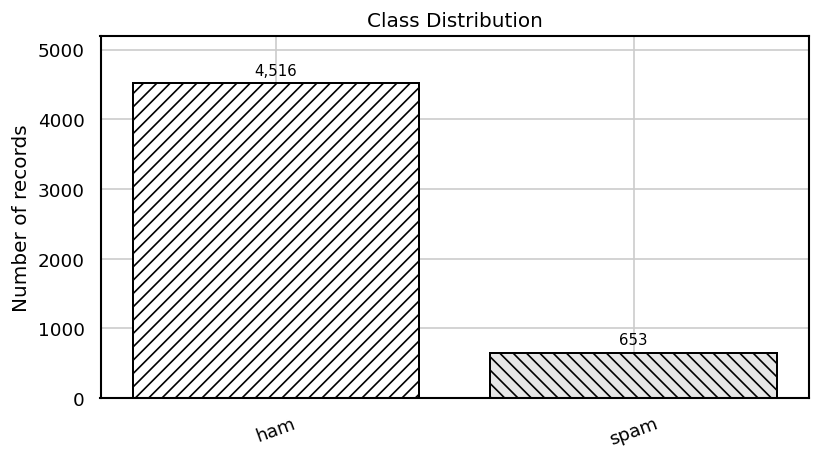

Train size: 4135
Test size: 1034


In [10]:
POSITIVE_LABEL = 'spam'

model_df = df.dropna(subset=["label"]).copy()
model_df["text"] = model_df["text"].fillna("").astype(str)
model_df = model_df[model_df["text"].str.strip().ne("")]
model_df = model_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Rows after cleaning:", len(model_df))
show_label_distribution(model_df, label_col="label")

X = model_df["text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

## 11. Support Vector Machine

Linear SVM classification report


,precision,recall,f1-score,support
ham,0.984598,0.991141,0.987859,903.000000
spam,0.936000,0.893130,0.914062,131.000000
accuracy,0.978723,0.978723,0.978723,0.978723
macro avg,0.960299,0.942135,0.950961,1034.000000
weighted avg,0.978441,0.978723,0.978509,1034.000000


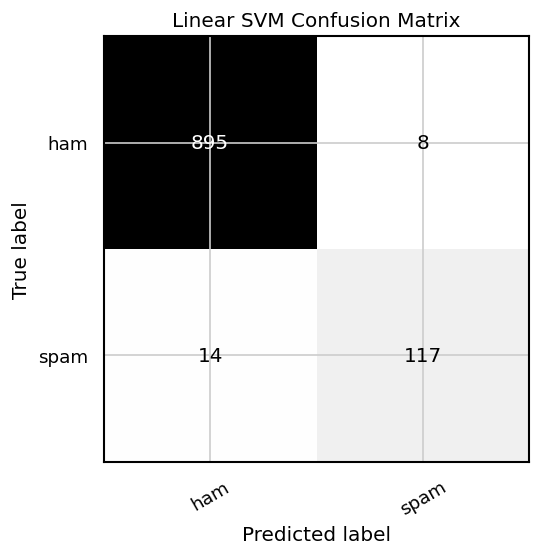

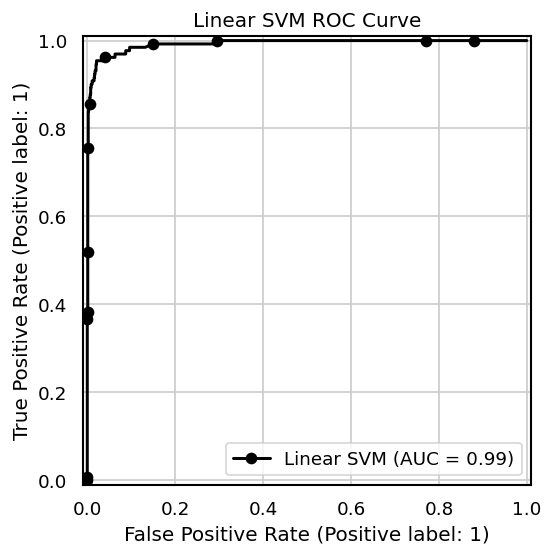

In [11]:
linear_svm = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=12000,
            ),
        ),
        (
            "model",
            LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=5000,
            ),
        ),
    ]
)

results = []
trained_models = {}

metrics, trained_model = evaluate_model(
    "Linear SVM",
    linear_svm,
    X_train,
    X_test,
    y_train,
    y_test,
    positive_label=POSITIVE_LABEL,
)
results.append(metrics)
trained_models["Linear SVM"] = trained_model

## 12. Decision Tree

Decision Tree classification report


,precision,recall,f1-score,support
ham,0.982353,0.924695,0.952653,903.000000
spam,0.630435,0.885496,0.736508,131.000000
accuracy,0.919729,0.919729,0.919729,0.919729
macro avg,0.806394,0.905096,0.844580,1034.000000
weighted avg,0.937768,0.919729,0.925269,1034.000000


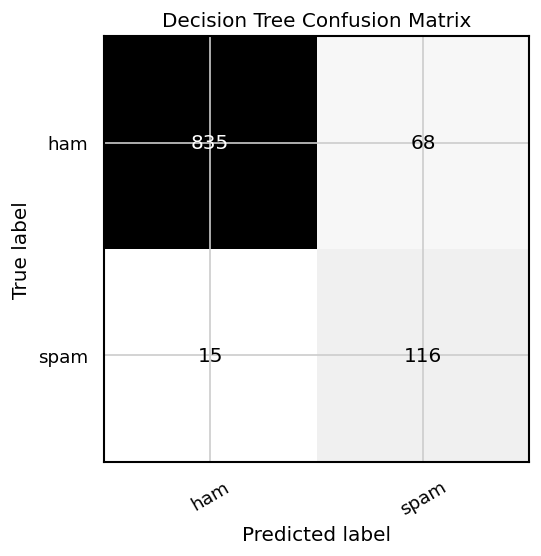

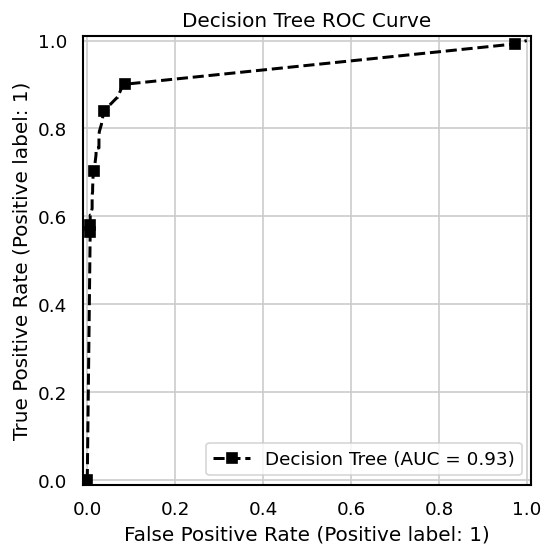

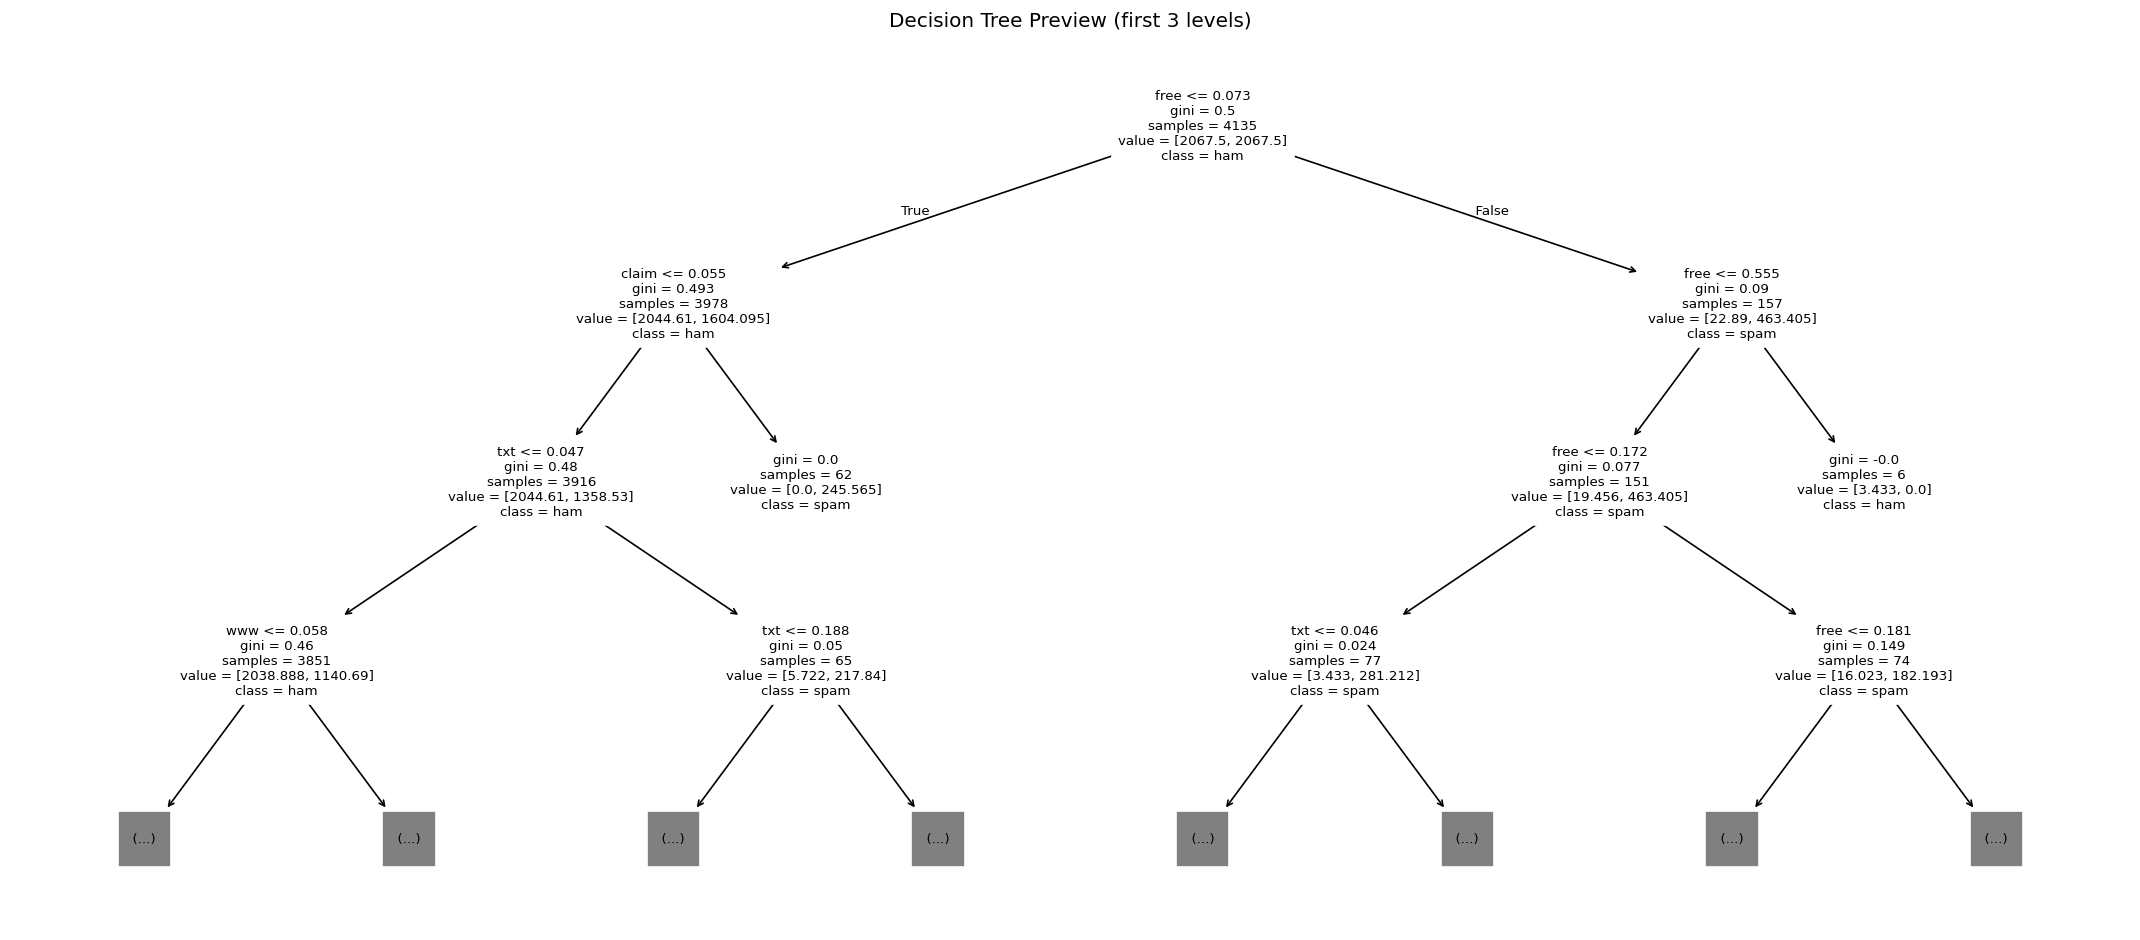

In [12]:
decision_tree = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=5000,
            ),
        ),
        (
            "model",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=40,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

metrics, trained_model = evaluate_model(
    "Decision Tree",
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test,
    positive_label=POSITIVE_LABEL,
)
results.append(metrics)
trained_models["Decision Tree"] = trained_model

plot_decision_tree_preview(trained_model, max_depth=3)

## 13. Model Comparison

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,roc_auc
0,Linear SVM,0.9787,0.9784,0.9787,0.9785,0.9925
1,Decision Tree,0.9197,0.9378,0.9197,0.9253,0.9333


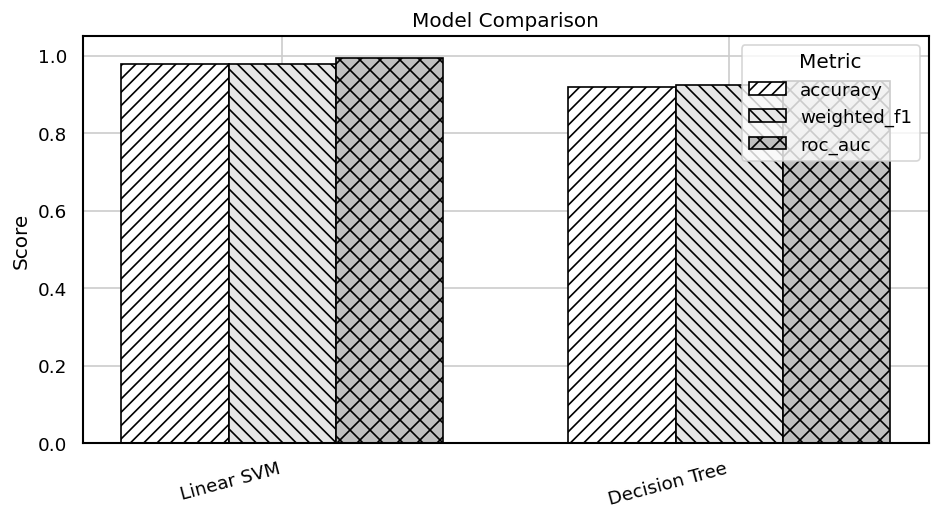

Best model by weighted F1: Linear SVM


In [13]:
results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
display(results_df.round(4))
plot_model_comparison(results_df)

best_model_name = results_df.loc[0, "model"]
print(f"Best model by weighted F1: {best_model_name}")

## 14. Quick Error Check

In [14]:
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test)

errors = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred,
})
errors = errors[errors["actual"] != errors["predicted"]]

print("Number of misclassified examples:", len(errors))
display(errors.head(15))

Number of misclassified examples: 22


,text,actual,predicted
1262,Your daily text from me – a favour this time,ham,spam
5137,Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min Gsex POBOX 2667 WC1N 3XX,spam,ham
521,You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750,spam,ham
1611,Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Calls£1/minMobsmoreLKPOBOX177HP51FL,spam,ham
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O £250 3 WANT £800,spam,ham
487,Are you free now?can i call now?,ham,spam
3599,"Please protect yourself from e-threats. SIB never asks for sensitive information like Passwords,ATM/SMS PIN thru email. Never share your password with anybody.",ham,spam
1423,Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 09099726395 Lucy x Calls£1/minMobsmoreLKPOBOX177HP...,spam,ham
3949,Missed call alert. These numbers called but left no message. 07008009200,spam,ham
4806,K k:) sms chat with me.,ham,spam
